# RAG: Langchain, Database for Embeddings, Clustering, and Paraphrasing using local LLMs

Retrieval-Augmented Generation (RAG) using Large Language Models (LLMs).
The process involves preparing data, creating the database, and running queries.

***Key Points***
- Multiple file formats accepted in any combination: PDF and plain text (`.txt`).
- Embedding database ChromaDB
- Paraphrasing
- Local LLM

## Important: Accessing HuggingFace
-  You may need to create a profile on HuggingFace to access models
-  You may need to generate Access Tokens on HuggingFace
  - You may need to generate SSH keys to access huggingface from linux shell
  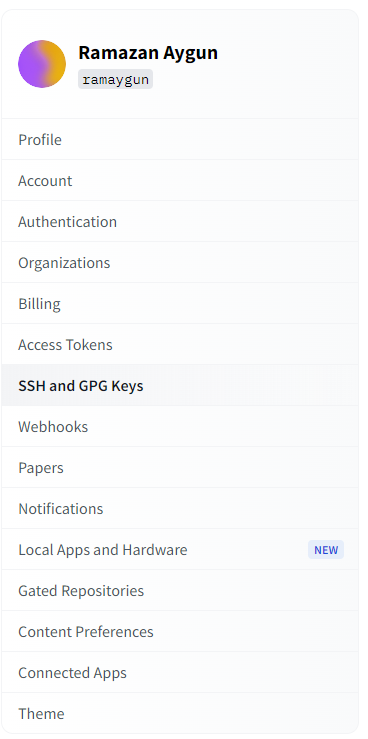
- You may need to agree with terms of model/dataset providers to be able to use them

## Setting up Imports


In [ ]:
# Sample library imports for a Python script that processes PDF documents, extracts text, and generates embeddings using a sentence transformer model. The script also utilizes LangGraph for state management and LangChain for document handling.

import os
import re
import requests
import numpy as np
import pandas as pd
from pypdf import PdfReader
from typing import TypedDict
from sentence_transformers import SentenceTransformer
from langgraph.graph import StateGraph, END
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
import random,torch,networkx as nx,seaborn as sns,matplotlib.pyplot as plt
import datasets
from datasets import load_dataset, load_from_disk, Dataset as HFDataset, DownloadConfig
from torchvision import transforms,models
from transformers import AutoImageProcessor, ViTForImageClassification
from peft import LoraConfig,get_peft_model
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_curve,auc
from torch.utils.data import Dataset,DataLoader
from pathlib import Path
from sklearn.model_selection import train_test_split
from getpass import getpass
from huggingface_hub import login

## Create Database

In [ ]:
def document_node(state):
    # This is the database of documents. You may also use other resources including web. The documents are stored in the following directory.
    files=["turner transformers.pdf","wolf transformers nlp.pdf","lin survey transformers.pdf"]
    texts=[]
    for f in files:
        reader=PdfReader(f)
        pdf_text="\n".join(page.extract_text() or "" for page in reader.pages)
        pdf_text=re.split(r"\n\s*(?:references|bibliography)\s*:?[ \t]*\n",pdf_text,maxsplit=1,flags=re.IGNORECASE)[0]
        texts.append(pdf_text)

    # Step. Split the data into smaller chunks

    # Text splitter parameters: splitter initially splits based on default characters \n\n, \n, or ' ' recursively. 
    # Merges splits that have less than chunk_size characters so that the size of a split does not surpass chunk_size characters.
    # chunk_overlap guarantees that the splits are overlapping with chunk_overlap characters
    splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
    state['chunks']=splitter.create_documents(texts)
    return state

## Agent 2: Embedding
Convert every document chunk into a vector representation using a sentence-embedding model. These vectors provide the numerical input for clustering.

**Output:** Chunk embeddings

In [ ]:
#use gpustat to see gpu utilization
device = torch.device("cuda:5")  # Use GPU 5

# Determine the embeddings to generate the database
embedding_model=SentenceTransformer("all-MiniLM-L6-v2")

def embedding_node(state):
    texts=[c.page_content for c in state['chunks']]
    state['embeddings']=embedding_model.encode(texts,show_progress_bar=True)
    return state

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4687.24it/s]


## Agent 4: Topic Extraction
For each cluster, send the medoid chunk to a local LLM and request a concise topic label and summary statement.

**Output:** Summary components

In [ ]:
OLLAMA_URL="http://localhost:11434/api/generate"
OLLAMA_MODEL="llama3"

def ollama_topic_node(state):
    labels={}
    summaries={}
    chunks=state['chunks']
    for cid,mid in state['medoids'].items():
        text=chunks[mid].page_content[:6000]
        prompt=(
            "Return exactly two lines:\n"
            "Topic Label: <3-8 word topic>\n"
            "Summary: <one concise sentence>\n\n"
            f"Text:\n{text}"
        )
        try:
            r=requests.post(
                OLLAMA_URL,
                json={
                    'model':OLLAMA_MODEL,
                    'prompt':prompt,
                    'stream':False,
                    'options':{'num_predict':128}
                },
                timeout=(5,180)
            )
            r.raise_for_status()
            out=r.json().get('response','').strip()
        except requests.RequestException as error:
            print(f"Topic generation failed for cluster {cid}: {error}")
            out='Topic Label: N/A\nSummary: unavailable'
        labels[cid]=out
        summaries[cid]=out
    state['topic_labels']=labels
    state['topic_summaries']=summaries
    return state

## Define the Shared Agent State
LangGraph passes this shared state between agents. It stores document chunks, embeddings, cluster assignments, centroids, medoids, topic outputs, and the final multi-document summary.

In [ ]:
class SummaryState(TypedDict):
    documents:list
    chunks:list
    embeddings:object

## Agent Orchestration
The agents operate as a pipeline:

`Document Processing -> Embedding`

LangGraph coordinates the state transitions and passes each agent's output to the next agent.

In [ ]:
workflow=StateGraph(SummaryState)
workflow.add_node('document',document_node)
workflow.add_node('embedding',embedding_node)
workflow.set_entry_point('document')
workflow.add_edge('document','embedding')
workflow.add_edge('embedding',END)
app=workflow.compile()

state={'documents':[],'chunks':[],'embeddings':None}
result=app.invoke(state)

## Dataset: WikiArt Genre Classification

Use the [`huggan/wikiart`](https://huggingface.co/datasets/huggan/wikiart) dataset. Remove `unknown_genre`, use `genre` as the class label, and preserve appropriate class proportions. Create training/validation subsets of 1,000, 5,000, and 10,000 total images, plus a separate stratified test set of 1,000 images. A smaller streamed sample may be used for development checks, but final results should use the required dataset sizes.

In [ ]:
from pathlib import Path
import datasets
from datasets import load_dataset, load_from_disk, Dataset as HFDataset, DownloadConfig
import pandas as pd
from sklearn.model_selection import train_test_split

from getpass import getpass
from huggingface_hub import login

datasets.enable_progress_bars()
datasets.utils.logging.set_verbosity_info()

token = getpass("Enter your Hugging Face token: ")
login(token=token)

SEED = 42
N = 2000  # total examples to download/read
TEST_SIZE = 200  # held-out test examples
dataset_sizes = [500, 1000]  # training subset sizes

# Download once to a local folder, then reuse that folder on later runs.
LOCAL_DATASET_DIR = Path("wikiart_train_local")
if LOCAL_DATASET_DIR.exists():
    print(f"Loading local dataset from {LOCAL_DATASET_DIR}...")
    downloaded = load_from_disk(str(LOCAL_DATASET_DIR))
else:
    print("Downloading WikiArt dataset...")
    download_config = DownloadConfig(disable_tqdm=False)
    downloaded = load_dataset(
        "huggan/wikiart",
        split="train",
        streaming=False,
        download_mode="reuse_dataset_if_exists",
        download_config=download_config,
        verification_mode="all_checks",
    )
    downloaded.save_to_disk(str(LOCAL_DATASET_DIR))
    print(f"Saved local dataset to {LOCAL_DATASET_DIR}")

sampled = downloaded.shuffle(seed=SEED).select(range(min(N, len(downloaded))))
all_df = sampled.to_pandas()

Loading local dataset from wikiart_train_local...


Loading cached shuffled indices for dataset at c:\Users\raygun\OneDrive - Kennesaw State University\PC Documents\Teaching\Courses\CS8267\Fall2026\assignments\code\wikiart_train_local\cache-db962588dac9d918.arrow


## Create Embeddings with Local LLM

In [5]:
import torch

#use gpustat to see gpu utilization
device = torch.device("cuda:5")  # Use GPU 5



In [6]:
# Step. Determine the embeddings to generate the database
instructor_embeddings = HuggingFaceInstructEmbeddings(
        #model_name="hkunlp/instructor-xl", model_kwargs={"device": "cuda"}
        model_name="hkunlp/instructor-xl", model_kwargs={"device": device}
        #model_name="hkunlp/instructor-xl", model_kwargs={"device": "cpu"}
    )

/mnt/bst/ramazan/raygun/.local/lib/python3.8/site-packages/InstructorEmbedding/instructor.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange


load INSTRUCTOR_Transformer
max_seq_length  512


/mnt/bst/ramazan/raygun/.local/lib/python3.8/site-packages/sentence_transformers/models/Dense.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torc

In [7]:
# Prepare the Chroma DB
# create simple ids for documents in the database
ids = [str(i) for i in range(1,len(texts)+1)]
        
Chroma.from_documents(
        documents=texts, embedding=instructor_embeddings, persist_directory=db_dir, ids=ids
)
vectordb = Chroma(embedding_function=instructor_embeddings, persist_directory=db_dir)

/mnt/bst/ramazan/raygun/.local/lib/python3.8/site-packages/langchain_core/_api/deprecation.py:139: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 0.4. An updated version of the class exists in the langchain-chroma package and should be used instead. To use it run `pip install -U langchain-chroma` and import as `from langchain_chroma import Chroma`.
  warn_deprecated(


## Accessing Embeddings

In [8]:
# Get relevant information
documents_vector = vectordb._collection.get(include=['embeddings','documents','metadatas'])
print(documents_vector['metadatas'][300])

{'page': 5, 'source': '../example/llm_papers/attention.pdf'}


In [9]:
documents_vector['embeddings'][200]

[0.0032591884955763817,
 -0.004178409930318594,
 0.04613891616463661,
 -0.03378907963633537,
 -0.06404976546764374,
 -0.058847133070230484,
 -0.061570990830659866,
 0.03285795822739601,
 -0.04640791192650795,
 -0.037610579282045364,
 0.016128450632095337,
 0.05016044154763222,
 -0.03400567173957825,
 -0.14549031853675842,
 -0.017170147970318794,
 -0.002447094302624464,
 0.03417225182056427,
 -0.04055478051304817,
 -0.026769371703267097,
 0.0035153706558048725,
 -0.018974898383021355,
 0.05307845026254654,
 -0.011572469025850296,
 0.030200988054275513,
 0.006695700343698263,
 -0.05108669772744179,
 0.027141250669956207,
 0.05229095742106438,
 -0.01051376573741436,
 0.02792234532535076,
 0.05070944502949715,
 -0.007199479732662439,
 0.04723643139004707,
 -0.0017889675218611956,
 0.03497595340013504,
 -0.01993188075721264,
 0.02925230748951435,
 -0.02080351673066616,
 0.024054108187556267,
 -0.0025633852928876877,
 -0.024870673194527626,
 0.05332740768790245,
 -0.01705833338201046,
 -0.02

In [10]:
#Convert embeddings to numpy array for processing

import numpy as np
embeddings = np.array(documents_vector['embeddings'])
embeddings.shape

(1127, 768)